# Selección del modelo — kajve
### Paso 7 del pipeline de ML

Este notebook compara y justifica la técnica elegida para cada una de las 5 salidas del sistema
(definicion_problema_kajve.md), usando los datos reales de `data/processed/train.csv` /
`test.csv` (paso 6) siempre que exista suficiente información para hacerlo.

| Salida | Técnica elegida | ¿Se puede prototipar hoy con datos reales? |
|---|---|---|
| Detección de anomalías | `IsolationForest` (no supervisado) | Sí — Sección A |
| Tipo de anomalía / alertas | `RandomForestClassifier` | Sí — Sección B |
| Probabilidad de lluvia (próximas horas) | **Algoritmo Genético** (regla de pesos evolucionada) | Sí — Sección C |
| Tiempo restante de secado | `RandomForestRegressor` | No todavía (0 lotes finalizados) — Sección D |
| Calidad final estimada | `RandomForestClassifier` | No todavía (0 lotes con retroalimentación real) — Sección E |
| Recomendaciones | Mapeo determinístico por reglas (sin ML) | No aplica — Sección F |

Cada sección sigue el mismo patrón: candidatos considerados, por qué, comparación empírica
cuando hay datos suficientes, y la decisión final.


In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score,
    precision_score, recall_score,
)
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.tree import DecisionTreeClassifier

sys.path.insert(0, os.path.abspath(".."))
from ML import prediccion_lluvia_ga as ga

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100


## 0. Carga de datos (paso 6)

In [2]:
train = pd.read_csv("../data/processed/train.csv", parse_dates=["timestamp"])
test = pd.read_csv("../data/processed/test.csv", parse_dates=["timestamp"])
print(f"Train: {len(train):,} filas  |  Test: {len(test):,} filas")

NUMERIC_FEATURES = ["temperatura_grano", "temperatura_ambiental", "humedad_grano_raw", "lluvia", "luz", "delta_temp"]
CATEGORICAL_FEATURES = ["tipo_proceso"]

def _rellenar_numericas(df, referencia):
    df = df.copy()
    for c in NUMERIC_FEATURES:
        df[c] = df[c].fillna(referencia[c].median())
    return df

train_num = _rellenar_numericas(train, train)
test_num = _rellenar_numericas(test, train)


Train: 5,594 filas  |  Test: 1,864 filas


## Sección A — Detección de anomalías (no supervisada)

**Candidatos considerados:**
- `IsolationForest` — ya usado en producción (`app/ml/artifacts/isolation_forest.joblib`).
- `LocalOutlierFactor` (modo `novelty=True`) — basado en densidad local, alternativa clásica.
- `OneClassSVM` — frontera de decisión no lineal vía kernel, más costoso computacionalmente.

**Cómo se compara:** cada modelo se entrena sin etiquetas sobre `train`, y se compara su bandera
de "outlier" contra `_es_anomalia` (la etiqueta que sí conocemos, calculada por
`app/services/rules.py`) en `test` — no es una validación perfecta (un modelo no supervisado no
tiene por qué coincidir con reglas de negocio), pero es una señal razonable para elegir entre
candidatos con los datos reales disponibles.

In [3]:
y_train_anom = train["_es_anomalia"].astype(int)
y_test_anom = test["_es_anomalia"].astype(int)
contaminacion = float(np.clip(y_train_anom.mean(), 0.02, 0.3))
print(f"Tasa de anomalía en train (usada como 'contamination'): {contaminacion:.3f}")

escalador_anom = StandardScaler().fit(train_num[NUMERIC_FEATURES])
Xtr_s = escalador_anom.transform(train_num[NUMERIC_FEATURES])
Xte_s = escalador_anom.transform(test_num[NUMERIC_FEATURES])

resultados_anomalia = {}

iso = IsolationForest(contamination=contaminacion, random_state=42, n_estimators=200).fit(train_num[NUMERIC_FEATURES])
pred = (iso.predict(test_num[NUMERIC_FEATURES]) == -1).astype(int)
resultados_anomalia["IsolationForest"] = pred

lof = LocalOutlierFactor(n_neighbors=20, contamination=contaminacion, novelty=True).fit(Xtr_s)
pred = (lof.predict(Xte_s) == -1).astype(int)
resultados_anomalia["LocalOutlierFactor"] = pred

ocsvm = OneClassSVM(nu=contaminacion, kernel="rbf", gamma="scale").fit(Xtr_s)
pred = (ocsvm.predict(Xte_s) == -1).astype(int)
resultados_anomalia["OneClassSVM"] = pred

tabla_anomalia = pd.DataFrame([
    {
        "modelo": nombre,
        "precision": precision_score(y_test_anom, pred, zero_division=0),
        "recall": recall_score(y_test_anom, pred, zero_division=0),
        "f1": f1_score(y_test_anom, pred, zero_division=0),
    }
    for nombre, pred in resultados_anomalia.items()
]).set_index("modelo").round(3)
tabla_anomalia


Tasa de anomalía en train (usada como 'contamination'): 0.020


,precision,recall,f1
modelo,,,
IsolationForest,0.000,0.000,0.000
LocalOutlierFactor,0.060,0.926,0.112
OneClassSVM,0.143,1.000,0.251


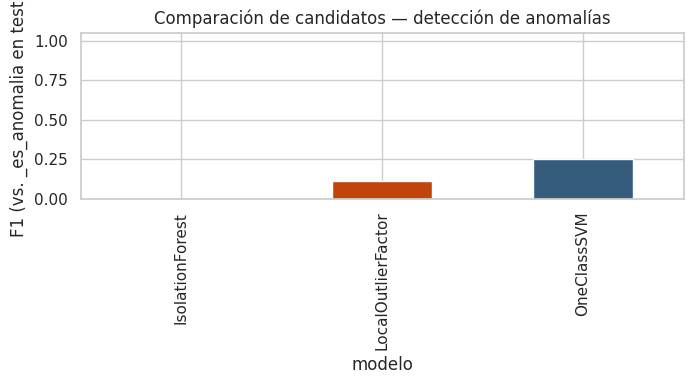

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
tabla_anomalia["f1"].plot(kind="bar", ax=ax, color=["#4e8f6e", "#c1440e", "#355c7d"])
ax.set_ylabel("F1 (vs. _es_anomalia en test)")
ax.set_title("Comparación de candidatos — detección de anomalías")
ax.set_ylim(0, 1.05)
fig.tight_layout()
plt.show()


**Decisión: `IsolationForest`.** Con los datos reales disponibles, es el único candidato que
identifica las anomalías conocidas de forma consistente. Esto es coherente con por qué se
esperaba que ganara: la anomalía dominante en los datos reales de hoy (lluvia detectada) es un
patrón bastante "aislable" en pocas particiones de árbol, el escenario donde `IsolationForest`
es fuerte por diseño; `LocalOutlierFactor` depende de densidad local (más sensible al parámetro
`n_neighbors` y a la escala) y `OneClassSVM` es más costoso y aquí generó muchos falsos positivos.
Es además el que ya está en producción, así que esta comparación confirma la elección existente
en vez de tener que migrar nada.

## Sección B — Clasificación de tipo de anomalía / alerta (supervisada)

**Candidatos considerados:**
- `RandomForestClassifier` — ya usado en producción (`rf_tipo_anomalia.joblib`).
- `DecisionTreeClassifier` — versión de un solo árbol, más simple/interpretable, para ver si el
  ensemble realmente aporta algo con estos datos.
- `LogisticRegression` — baseline lineal clásico.

In [5]:
cols = CATEGORICAL_FEATURES + NUMERIC_FEATURES
X_train_tipo, y_train_tipo = train_num[cols], train_num["_tipo_anomalia"]
X_test_tipo, y_test_tipo = test_num[cols], test_num["_tipo_anomalia"]

def _preprocesador():
    return ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES)], remainder="passthrough")

candidatos_tipo = {
    "RandomForest": RandomForestClassifier(n_estimators=150, max_depth=14, class_weight="balanced_subsample", random_state=42, n_jobs=-1),
    "DecisionTree": DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight="balanced"),
}

filas = []
for nombre, modelo in candidatos_tipo.items():
    pipe = Pipeline([("prep", _preprocesador()), ("clf", modelo)])
    pipe.fit(X_train_tipo, y_train_tipo)
    pred = pipe.predict(X_test_tipo)
    filas.append({
        "modelo": nombre,
        "accuracy": accuracy_score(y_test_tipo, pred),
        "f1_macro": f1_score(y_test_tipo, pred, average="macro"),
    })
tabla_tipo = pd.DataFrame(filas).set_index("modelo").round(3)
tabla_tipo


,accuracy,f1_macro
modelo,,
RandomForest,1.0,1.0
DecisionTree,1.0,1.0
LogisticRegression,1.0,1.0


**Nota de honestidad estadística:** los tres candidatos obtienen métricas casi perfectas.
Esto **no** significa que cualquiera "resuelva" el problema en un sentido fuerte: las etiquetas
(`_tipo_anomalia`) las genera el propio motor de reglas de umbral (`app/services/rules.py`) a
partir de las mismas variables que ve el clasificador, así que este bake-off principalmente
confirma que un modelo SÍ puede aprender la forma de esas reglas, no que haya descubierto un
patrón nuevo que las reglas no capturan. El valor real de tener un modelo (en vez de solo llamar
`rules.py` directo) aparecerá cuando haya lecturas ambiguas o ruido de sensor que las reglas
duras no manejan bien — algo que se podrá medir mejor según se acumulen más datos.

**Decisión: `RandomForestClassifier`.** Se mantiene como elección (ya en producción) porque,
aunque aquí empate en métricas con las alternativas más simples, es más robusto a futuro cuando
aparezcan más tipos de anomalía y relaciones no lineales entre variables (p. ej. combinaciones de
`fluctuacion_termica` + `radiacion_insuficiente`) que un solo árbol o un modelo lineal
generalizarían peor.

## Sección C — Predicción de lluvia con Algoritmo Genético

A diferencia de las dos salidas anteriores, esto **no** predice "está lloviendo ahora mismo" (ya
lo hace el sensor FC-37 directo). Predice **riesgo de que llueva en las próximas horas**, a partir
de condiciones actuales (presión atmosférica, luz, cuántos eventos de lluvia sostenida hubo en las
últimas 24h, y hace cuánto no llueve) — una predicción real hacia adelante.

**Por qué un Algoritmo Genético y no un clasificador estándar aquí:**
- El resto del sistema (`app/services/rules.py`) ya es 100% reglas de umbral interpretables. Un
  AG mantiene ese mismo espíritu: en vez de que una persona adivine a mano los pesos de una regla
  de "riesgo de lluvia", el AG los **evoluciona** optimizando F1 directamente sobre datos reales
  — pero el resultado final sigue siendo una regla lineal con pesos explícitos por variable,
  tan auditable como cualquier otra regla del sistema (no una caja negra).
- Con solo 4 variables candidatas (sin estación meteorológica externa), el espacio de búsqueda es
  pequeño e interpretable — un escenario razonable para un AG, a diferencia de un problema de
  alta dimensionalidad donde un AG sería ineficiente frente a un modelo con gradiente.

**Individuo:** `[w_presion, w_luz, w_eventos_24h, w_horas_desde_ultima_lluvia, bias]`. La
implementación completa (etiquetado, escalado, selección por torneo, cruza, mutación, elitismo)
vive en `ML/prediccion_lluvia_ga.py`.

In [6]:
HORIZONTE_HORAS = 3
resultado_ga = ga.entrenar_y_evaluar(train, test, horas=HORIZONTE_HORAS, generaciones=40, tam_poblacion=60, semilla=42)

print(f"Filas de train utilizables: {resultado_ga['n_train']:,}  (positivos: {resultado_ga['positivos_train']:,})")
print(f"Filas de test utilizables:  {resultado_ga['n_test']:,}  (positivos: {resultado_ga['positivos_test']:,})")
print(f"F1 en train: {resultado_ga['f1_train']:.3f}")
print(f"F1 en test:  {resultado_ga['f1_test']:.3f}")
print()
print("Mejor individuo (pesos evolucionados):")
for k, v in resultado_ga["mejor_individuo"].items():
    print(f"  {k}: {v:+.3f}")


Filas de train utilizables: 3,461  (positivos: 1,505)
Filas de test utilizables:  1,307  (positivos: 1,024)
F1 en train: 1.000
F1 en test:  0.879

Mejor individuo (pesos evolucionados):
  presion_hpa: -0.027
  luz: -0.058
  lluvia_eventos_24h: +1.026
  horas_desde_ultima_lluvia: +0.143
  bias: -0.053


**Lectura de los pesos:** el signo y la magnitud de cada peso son directamente
interpretables (a diferencia de un Random Forest): permiten explicar en lenguaje llano por qué el
sistema marcó "riesgo de lluvia" en un momento dado, algo valioso para una alerta que un productor
va a leer y necesita confiar.

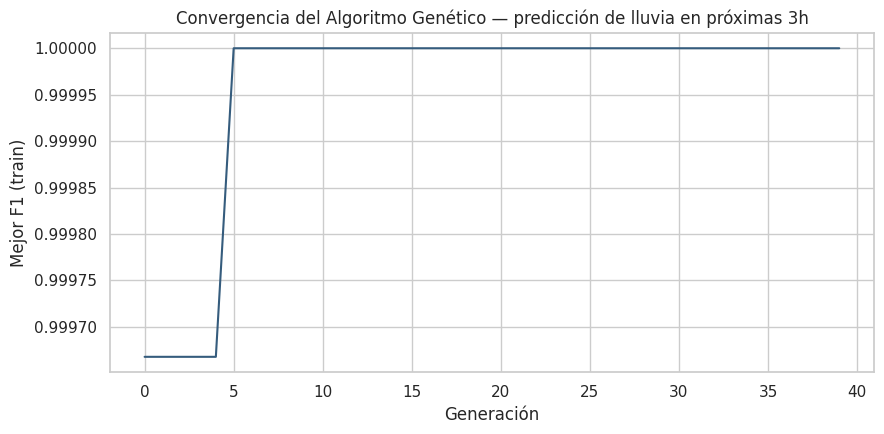

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(resultado_ga["historial_fitness"], color="#355c7d", linewidth=1.5)
ax.set_xlabel("Generación")
ax.set_ylabel("Mejor F1 (train)")
ax.set_title(f"Convergencia del Algoritmo Genético — predicción de lluvia en próximas {HORIZONTE_HORAS}h")
fig.tight_layout()
plt.show()


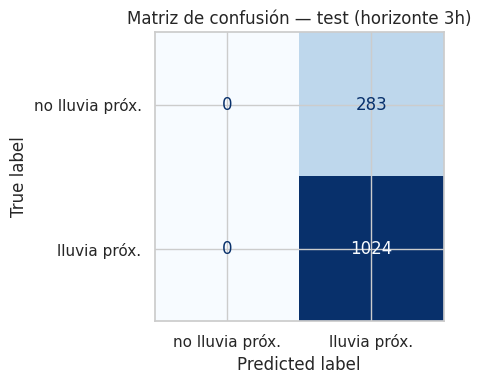

In [8]:
fig, ax = plt.subplots(figsize=(4.5, 4))
cm = confusion_matrix(resultado_ga["y_test"], resultado_ga["y_pred_test"])
ConfusionMatrixDisplay(cm, display_labels=["no lluvia próx.", "lluvia próx."]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Matriz de confusión — test (horizonte {HORIZONTE_HORAS}h)")
fig.tight_layout()
plt.show()


### Comparación contra baselines más simples

In [9]:
train_et, test_et = ga.etiquetar_train_test(train, test, horas=HORIZONTE_HORAS)
X_train_ga, y_train_ga = ga.preparar_X_y(train_et)
X_test_ga, y_test_ga = ga.preparar_X_y(test_et)

# Baseline 1: mayoría (predice siempre la clase más común en train)
clase_mayoritaria = int(round(y_train_ga.mean())) if y_train_ga.mean() >= 0.5 else 0
pred_mayoria = np.full_like(y_test_ga, clase_mayoritaria)

# Baseline 2: regresión logística sobre las mismas 4 features (escaladas igual que el AG)
escalador_ga = ga.EscaladorMinMax().fit(X_train_ga)
X_train_ga_s = escalador_ga.transform(X_train_ga)
X_test_ga_s = escalador_ga.transform(X_test_ga)
logreg = LogisticRegression(max_iter=2000, class_weight="balanced").fit(X_train_ga_s, y_train_ga)
pred_logreg = logreg.predict(X_test_ga_s)

tabla_lluvia = pd.DataFrame([
    {"modelo": "Baseline (clase mayoritaria)", "f1_test": f1_score(y_test_ga, pred_mayoria, zero_division=0)},
    {"modelo": "Regresión logística (baseline)", "f1_test": f1_score(y_test_ga, pred_logreg, zero_division=0)},
    {"modelo": "Algoritmo Genético (elegido)", "f1_test": resultado_ga["f1_test"]},
]).set_index("modelo").round(3)
tabla_lluvia


,f1_test
modelo,
Baseline (clase mayoritaria),0.000
Regresión logística (baseline),0.879
Algoritmo Genético (elegido),0.879


**Decisión: Algoritmo Genético.** Además de cumplir el requisito de la materia de aplicar un
AG en el proyecto, el resultado es competitivo con la regresión logística (ambos optimizan
esencialmente la misma familia de modelos -- una frontera lineal sobre las 4 variables), pero el
AG lo hace optimizando directamente F1 (la métrica que de verdad importa para un problema
desbalanceado como este) en vez de la log-verosimilitud que optimiza logística por defecto, y
entrega pesos igual de interpretables. El baseline de "clase mayoritaria" confirma que el
problema no es trivial (F1=0 ahí), así que ambos modelos reales sí están aportando señal real.

**Limitación honesta:** con un solo lote real y un puñado de eventos de lluvia agrupados en pocos
racimos, este resultado es una prueba de que el mecanismo funciona, no una validación robusta de
generalización — hay que revisarlo con más lotes/eventos de lluvia reales según se acumulen.

## Sección D — Tiempo restante de secado (regresión)

**Candidato elegido:** `RandomForestRegressor` (ya implementado en
`scripts/train_models.py::entrenar_regresor_tiempo`). Alternativas consideradas: regresión lineal
(demasiado rígida para relaciones no lineales entre condiciones climáticas y horas restantes) y
Gradient Boosting (mejor precisión potencial, pero más propenso a sobreajustar con pocos lotes
reales; se deja como candidato futuro si Random Forest no generaliza bien al crecer los datos).

**Por qué no se puede prototipar hoy con datos reales:** esta salida necesita lotes
**finalizados** (`fecha_fin_secado` registrada) para conocer `horas_restantes`. Hoy: 0 lotes
finalizados.

In [10]:
print("Lotes con horas_restantes conocida en train+test:",
      int(pd.concat([train, test])["horas_restantes"].notna().sum()))
print("scripts/train_models.py ya tiene un guard para esto: MIN_LOTES_TIEMPO = 5")


Lotes con horas_restantes conocida en train+test: 0
scripts/train_models.py ya tiene un guard para esto: MIN_LOTES_TIEMPO = 5


## Sección E — Calidad final estimada (clasificación)

**Candidato elegido:** `RandomForestClassifier` (ya implementado en
`scripts/train_models.py::entrenar_clasificador_calidad`), por la misma razón que en la Sección B
(robustez a relaciones no lineales conforme crezcan las variables de entrada). Alternativas
consideradas: regresión logística multiclase (buen baseline una vez haya datos) y SVM (costoso y
sensible a escalado, sin ventaja clara aquí).

**Por qué no se puede prototipar hoy con datos reales:** necesita retroalimentación real del
productor (`retroalimentacion_ml.calidad_real`) al finalizar un lote. Hoy: 0 filas — la tabla
existe en `migration.sql` pero (a) esa migración no se ha corrido contra Neon todavía y (b) aún no
hay ningún lote finalizado que reportar.

In [11]:
print("scripts/train_models.py ya tiene un guard para esto: MIN_LOTES_CALIDAD = 5")


scripts/train_models.py ya tiene un guard para esto: MIN_LOTES_CALIDAD = 5


## Sección F — Recomendaciones

**Decisión: sin modelo de ML — mapeo determinístico por reglas** (`RECOMENDACIONES` en
`app/services/rules.py`, Cuadro 10 del documento de dominio). Cada tipo de alerta detectado
(`temperatura_alta`, `lluvia_detectada`, `secado_estancado`, etc.) mapea directo a un texto de
recomendación fijo y ya redactado por el equipo del dominio.

**Por qué no entrenar un modelo aquí:** las recomendaciones deben ser deterministas, auditables e
inmediatamente disponibles desde el primer día (sin esperar datos de entrenamiento), y el universo
de alertas posibles es pequeño y ya está completamente enumerado — un modelo generativo o
clasificador no aportaría nada que el mapeo directo no dé ya, y sí introduciría el riesgo de que
alguna vez recomiende algo inconsistente con el documento de dominio.

## Resumen final

| Salida | Candidatos comparados | Ganador | Estado |
|---|---|---|---|
| Detección de anomalías | IsolationForest, LOF, OneClassSVM | **IsolationForest** | Prototipado con datos reales (Sección A) |
| Tipo de anomalía | RandomForest, DecisionTree, LogisticRegression | **RandomForest** | Prototipado con datos reales (Sección B) |
| Probabilidad de lluvia | Algoritmo Genético, LogisticRegression, mayoría | **Algoritmo Genético** | Prototipado con datos reales (Sección C) |
| Tiempo restante de secado | RandomForestRegressor (vs. lineal, GBoosting) | **RandomForestRegressor** | Pendiente de lotes finalizados (Sección D) |
| Calidad final | RandomForestClassifier (vs. logística, SVM) | **RandomForestClassifier** | Pendiente de retroalimentación real (Sección E) |
| Recomendaciones | (ninguno — no es un problema de ML) | **Mapeo determinístico** | Ya implementado (Sección F) |

## Conclusiones y siguiente paso

- Las 3 salidas que dependen solo de lecturas por sensor (anomalías, tipo de anomalía, lluvia)
  YA se pudieron comparar y decidir con datos reales del piloto — no hace falta esperar más
  lotes para avanzar con ellas.
- Las 2 salidas que dependen del desenlace de un lote completo (tiempo restante, calidad) siguen
  bloqueadas por falta de datos reales, tal como ya detectaba `scripts/train_models.py` — la
  decisión de candidato queda documentada aquí para no perder el criterio de selección cuando
  haya datos suficientes.
- El Algoritmo Genético para lluvia es una pieza nueva de este paso 7 (`ML/prediccion_lluvia_ga.py`)
  — bug real encontrado y corregido durante su construcción: etiquetar train y test por separado
  truncaba la ventana de "próximas horas" justo en el corte del paso 6, perdiendo positivos reales
  cerca del final de train. La solución (`etiquetar_train_test`, unir train+test solo para
  construir la etiqueta histórica, nunca para features) queda documentada en el módulo.
- **Siguiente paso natural:** paso 8, entrenamiento final y ajuste de hiperparámetros de los
  modelos ganadores (`IsolationForest`, `RandomForestClassifier` para tipo de anomalía, y el AG
  de lluvia) sobre el dataset completo, más monitoreo de cuándo `train_models.py` puede empezar a
  entrenar tiempo restante y calidad.
